In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import argparse
import matplotlib.pyplot as plt

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMForecaster:
    def __init__(self, data_path, window_size, hidden_size, num_layers, epochs, batch_size, lr):
        self.data_path = data_path
        self.window_size = window_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.mean = 0
        self.std = 1
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None
        self.model = None
        self.criterion = nn.MSELoss()
        self.optimizer = None

    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = out[:, -1, :]
            out = self.fc(out)
            return out

    def prepare_data(self):
        data = pd.read_csv(self.data_path).values.astype(np.float32)
        train_size = int(len(data) * 0.7)
        train_data = data[:train_size]
        test_data = data[train_size - self.window_size:]
        self.mean = train_data.mean()
        self.std = train_data.std()
        train_data = (train_data - self.mean) / self.std
        test_data = (test_data - self.mean) / self.std
        
        def create_samples(dataset):
            X, y = [], []
            for i in range(len(dataset)-self.window_size):
                X.append(dataset[i:i+self.window_size])
                y.append(dataset[i+self.window_size])
            return np.array(X), np.array(y)

        X_train, y_train = create_samples(train_data)
        X_test, y_test = create_samples(test_data)
        
        self.X_train = torch.from_numpy(X_train).float().view(-1, self.window_size, 1)
        self.y_train = torch.from_numpy(y_train).float().view(-1, 1)
        self.X_test = torch.from_numpy(X_test).float().view(-1, self.window_size, 1)
        self.y_test = torch.from_numpy(y_test).float().view(-1, 1)

    def build_model(self):
        self.model = self.LSTMModel(1, self.hidden_size, self.num_layers).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

    def train(self):
        train_dataset = TimeSeriesDataset(self.X_train, self.y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
    
        loss_filename = f"{self.window_size}-{self.hidden_size}-{self.num_layers}-{self.epochs}-{self.batch_size}-{self.lr}-loss_results.txt"
        
        self.model.train()
        with open(loss_filename, 'w') as f:  
            f.write("Epoch, Loss\n") 
            
            for epoch in range(self.epochs):
                total_loss = 0
                for X_batch, y_batch in train_loader:
                    X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                    self.optimizer.zero_grad()
                    outputs = self.model(X_batch)
                    loss = self.criterion(outputs, y_batch)
                    loss.backward()
                    self.optimizer.step()
                    total_loss += loss.item()
                
                avg_loss = total_loss / len(train_loader)
                if (epoch+1)%10==0:
                    print(f'Epoch [{epoch+1}/{self.epochs}], Loss: {avg_loss:.4f}') 
                f.write(f"{epoch+1}, {avg_loss:.4f}\n") 
        
        torch.save(self.model.state_dict(), 'lstm_model.pth')
        print(f"Loss results saved to: {loss_filename}")

    def test(self):
        test_dataset = TimeSeriesDataset(self.X_test, self.y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        self.model.load_state_dict(torch.load('lstm_model.pth'))
        self.model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = self.model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())
        predictions = np.array(predictions) * self.std + self.mean
        actuals = np.array(actuals) * self.std + self.mean
        mse = np.mean((predictions - actuals) ** 2)
        print(f'Test MSE: {mse:.4f}')
        return actuals, predictions

    def plot_results(self, actuals, predictions):
        plt.figure(figsize=(12, 6))
        plt.plot(actuals, label='Actual')
        plt.plot(predictions, label='Predicted')
        plt.legend()
        plt.title('Time Series Prediction Results')
        filename = f"{self.window_size}-{self.hidden_size}-{self.num_layers}-{self.epochs}-{self.batch_size}-{self.lr}-prediction_results.png"
        #plt.show()
        plt.savefig(filename)
        plt.close()

In [2]:
window_sizes = [5, 10, 15]
hidden_sizes = [100, 200]
num_layerss = [1, 3, 5]
epochs = 50
batch_size = 32
lr = 0.001

results = []
best_metrics = {'mse': float('inf')}
best_params = {}

for ws in window_sizes:
    for hs in hidden_sizes:
        for nl in num_layerss:
            print(f"\nTraining model with WS={ws}, HS={hs}, Layers={nl}")
            
            forecaster = LSTMForecaster(
                data_path='/kaggle/input/ucr-ecg/UCR_ECG1_10000_11800_12100.txt',
                window_size=ws,
                hidden_size=hs,
                num_layers=nl,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr
            )

            forecaster.prepare_data()
            forecaster.build_model()
            
            forecaster.train()
            actuals, predictions = forecaster.test()
            mse = ((actuals - predictions) ** 2).mean()
            
            current_result = {
                'window_size': ws,
                'hidden_size': hs,
                'num_layers': nl,
                'mse': mse,
                'actuals': actuals,
                'predictions': predictions
            }
            results.append(current_result)
            
            if mse < best_metrics['mse']:
                best_metrics['mse'] = mse
                best_params = {
                    'window_size': ws,
                    'hidden_size': hs,
                    'num_layers': nl
                }
                print(f"New best model! MSE: {mse:.4f}")
            
            forecaster.plot_results(actuals, predictions)

print("\nHyperparameter search complete!")
print(f"Best parameters: {best_params}")
print(f"Best MSE: {best_metrics['mse']:.4f}")

best_result = next(r for r in results if (r['window_size'] == best_params['window_size'] and 
                                         r['hidden_size'] == best_params['hidden_size'] and 
                                         r['num_layers'] == best_params['num_layers']))
print("\nPlotting best model results...")
forecaster.plot_results(best_result['actuals'], best_result['predictions'])


Training model with WS=5, HS=100, Layers=1
Epoch [10/50], Loss: 0.0090
Epoch [20/50], Loss: 0.0071
Epoch [30/50], Loss: 0.0062
Epoch [40/50], Loss: 0.0056
Epoch [50/50], Loss: 0.0052
Loss results saved to: 5-100-1-50-32-0.001-loss_results.txt


/tmp/ipykernel_19/1179700522.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('lstm_model.pth'))


Test MSE: 0.8206
New best model! MSE: 0.8206

Training model with WS=5, HS=100, Layers=3
Epoch [10/50], Loss: 0.0076
Epoch [20/50], Loss: 0.0059
Epoch [30/50], Loss: 0.0050
Epoch [40/50], Loss: 0.0045
Epoch [50/50], Loss: 0.0043
Loss results saved to: 5-100-3-50-32-0.001-loss_results.txt


/tmp/ipykernel_19/1179700522.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('lstm_model.pth'))


Test MSE: 0.7556
New best model! MSE: 0.7556

Training model with WS=5, HS=100, Layers=5
Epoch [10/50], Loss: 0.0082
Epoch [20/50], Loss: 0.0062
Epoch [30/50], Loss: 0.0052
Epoch [40/50], Loss: 0.0050
Epoch [50/50], Loss: 0.0050
Loss results saved to: 5-100-5-50-32-0.001-loss_results.txt


...

Test MSE: 0.6449

Training model with WS=15, HS=200, Layers=3
Epoch [10/50], Loss: 0.0073
Epoch [20/50], Loss: 0.0049
Epoch [30/50], Loss: 0.0042
Epoch [40/50], Loss: 0.0037
Epoch [50/50], Loss: 0.0032
Loss results saved to: 15-200-3-50-32-0.001-loss_results.txt


/tmp/ipykernel_19/1179700522.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('lstm_model.pth'))


Test MSE: 0.7120

Training model with WS=15, HS=200, Layers=5
Epoch [10/50], Loss: 0.0085
Epoch [20/50], Loss: 0.0053
Epoch [30/50], Loss: 0.0045
Epoch [40/50], Loss: 0.0040
Epoch [50/50], Loss: 0.0035
Loss results saved to: 15-200-5-50-32-0.001-loss_results.txt


/tmp/ipykernel_19/1179700522.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('lstm_model.pth'))


Test MSE: 0.9846

Hyperparameter search complete!
Best parameters: {'window_size': 10, 'hidden_size': 100, 'num_layers': 5}
Best MSE: 0.6359

Plotting best model results...


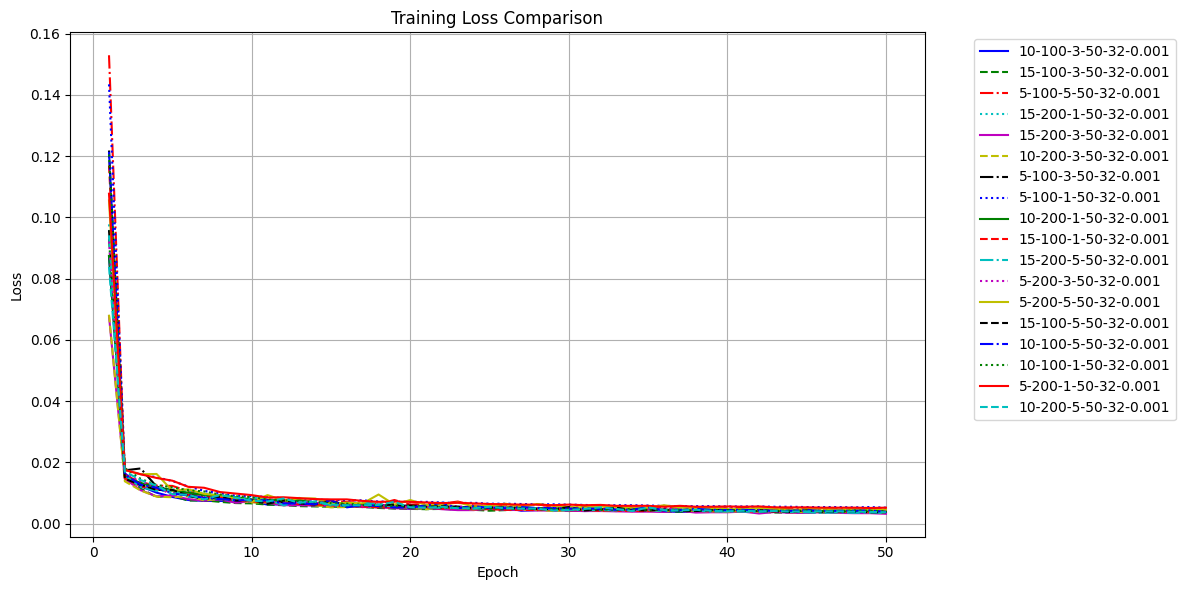

Comparison plot saved to: loss_comparison.png


In [3]:
import glob
import matplotlib.pyplot as plt
import pandas as pd

loss_files = glob.glob("/kaggle/working/*-loss_results.txt")

plt.figure(figsize=(12, 6))

line_styles = ['-', '--', '-.', ':']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

for i, loss_file in enumerate(loss_files):
    try:
        params = loss_file.split('/')[-1].split('-loss_results.txt')[0]
        
        data = pd.read_csv(loss_file, header=0, names=['Epoch', 'Loss'], delimiter=',')
        
        if not data.empty:
            style_idx = i % len(line_styles)
            color_idx = i % len(colors)
            
            plt.plot(data['Epoch'], data['Loss'], 
                    label=params,
                    linestyle=line_styles[style_idx],
                    color=colors[color_idx])
    
    except Exception as e:
        print(f"Error processing {loss_file}: {str(e)}")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True)

plt.tight_layout()

comparison_filename = "loss_comparison.png"
plt.savefig(comparison_filename, bbox_inches='tight')
plt.show()
print(f"Comparison plot saved to: {comparison_filename}")

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import argparse
import matplotlib.pyplot as plt

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMForecaster:
    def __init__(self, data_path, window_size, forecast_horizon, hidden_size, num_layers, epochs, batch_size, lr):
        self.data_path = data_path
        self.window_size = window_size
        self.forecast_horizon = forecast_horizon 
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.mean = 0
        self.std = 1
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None
        self.model = None
        self.criterion = nn.MSELoss()
        self.optimizer = None

    class LSTMModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers, forecast_horizon):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            self.fc = nn.Linear(hidden_size, forecast_horizon)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = out[:, -1, :]
            out = self.fc(out)
            return out

    def prepare_data(self):
        data = pd.read_csv(self.data_path).values.astype(np.float32)
        train_size = int(len(data) * 0.7)
        train_data = data[:train_size]
        test_data = data[train_size - self.window_size:]
        self.mean = train_data.mean()
        self.std = train_data.std()
        train_data = (train_data - self.mean) / self.std
        test_data = (test_data - self.mean) / self.std

        def create_samples(dataset):
            X, y = [], []
            for i in range(len(dataset)-self.window_size-self.forecast_horizon+1):
                X.append(dataset[i:i+self.window_size])
                y.append(dataset[i+self.window_size:i+self.window_size+self.forecast_horizon])
            return np.array(X), np.array(y)

        X_train, y_train = create_samples(train_data)
        X_test, y_test = create_samples(test_data)

        self.X_train = torch.from_numpy(X_train).float().view(-1, self.window_size, 1)
        self.y_train = torch.from_numpy(y_train).float().view(-1, self.forecast_horizon)
        self.X_test = torch.from_numpy(X_test).float().view(-1, self.window_size, 1)
        self.y_test = torch.from_numpy(y_test).float().view(-1, self.forecast_horizon)

    def build_model(self):
        self.model = self.LSTMModel(1, self.hidden_size, self.num_layers, self.forecast_horizon).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

    def train(self):
        train_dataset = TimeSeriesDataset(self.X_train, self.y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
    
        loss_filename = f"{self.window_size}-{self.forecast_horizon}-{self.hidden_size}-{self.num_layers}-{self.epochs}-{self.batch_size}-{self.lr}-loss_results.txt"
        
        self.model.train()
        with open(loss_filename, 'w') as f:  
            f.write("Epoch, Loss\n") 
            
            for epoch in range(self.epochs):
                total_loss = 0
                for X_batch, y_batch in train_loader:
                    X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                    self.optimizer.zero_grad()
                    outputs = self.model(X_batch)
                    loss = self.criterion(outputs, y_batch)
                    loss.backward()
                    self.optimizer.step()
                    total_loss += loss.item()
                
                avg_loss = total_loss / len(train_loader)
                print(f'Epoch [{epoch+1}/{self.epochs}], Loss: {avg_loss:.4f}')
                
                f.write(f"{epoch+1}, {avg_loss:.4f}\n") 
        
        torch.save(self.model.state_dict(), 'lstm_model.pth')
        print(f"Loss results saved to: {loss_filename}")

    def test(self):
        test_dataset = TimeSeriesDataset(self.X_test, self.y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)
        
        self.model.load_state_dict(torch.load('lstm_model.pth'))
        self.model.eval()
        predictions = []
        actuals = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = self.model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())

        predictions = np.array(predictions) * self.std + self.mean
        actuals = np.array(actuals) * self.std + self.mean
        mse = np.mean((predictions - actuals) ** 2)
        print(f'Test MSE: {mse:.4f}')
        return actuals, predictions

    def plot_results(self, actuals, predictions):
        plt.figure(figsize=(12, 6))
        
        plt.plot(actuals[:, 0], label='Actual (first step)')
        plt.plot(predictions[:, 0], label='Predicted (first step)')
        
        
        plt.legend()
        plt.title(f'Time Series Prediction Results ({self.forecast_horizon}-step forecast)')
        filename = f"{self.window_size}-{self.forecast_horizon}-{self.hidden_size}-{self.num_layers}-{self.epochs}-{self.batch_size}-{self.lr}-prediction_results.png"
        plt.savefig(filename)
        plt.close()

In [5]:
forecaster = LSTMForecaster(
    data_path='/kaggle/input/ucr-ecg/UCR_ECG1_10000_11800_12100.txt',
    window_size=10,
    forecast_horizon=3,  
    hidden_size=50,
    num_layers=1,
    epochs=50,
    batch_size=32,
    lr=0.001
)

forecaster.prepare_data()
forecaster.build_model()

forecaster.train()
actuals, predictions = forecaster.test()
forecaster.plot_results(actuals, predictions)

Epoch [1/50], Loss: 0.3304
Epoch [2/50], Loss: 0.1183
Epoch [3/50], Loss: 0.0893
Epoch [4/50], Loss: 0.0773
Epoch [5/50], Loss: 0.0668
Epoch [6/50], Loss: 0.0595
Epoch [7/50], Loss: 0.0543
Epoch [8/50], Loss: 0.0494
Epoch [9/50], Loss: 0.0457
Epoch [10/50], Loss: 0.0422
Epoch [11/50], Loss: 0.0386
Epoch [12/50], Loss: 0.0372
Epoch [13/50], Loss: 0.0338
Epoch [14/50], Loss: 0.0331
Epoch [15/50], Loss: 0.0321
Epoch [16/50], Loss: 0.0299
Epoch [17/50], Loss: 0.0283
Epoch [18/50], Loss: 0.0275
Epoch [19/50], Loss: 0.0258
Epoch [20/50], Loss: 0.0260
Epoch [21/50], Loss: 0.0250
Epoch [22/50], Loss: 0.0243
Epoch [23/50], Loss: 0.0232
Epoch [24/50], Loss: 0.0227
Epoch [25/50], Loss: 0.0225
Epoch [26/50], Loss: 0.0214
Epoch [27/50], Loss: 0.0213
Epoch [28/50], Loss: 0.0205
Epoch [29/50], Loss: 0.0207
Epoch [30/50], Loss: 0.0201
Epoch [31/50], Loss: 0.0195
Epoch [32/50], Loss: 0.0194
Epoch [33/50], Loss: 0.0192
Epoch [34/50], Loss: 0.0189
Epoch [35/50], Loss: 0.0185
Epoch [36/50], Loss: 0.0188
E

/tmp/ipykernel_19/1187078388.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('lstm_model.pth'))


Test MSE: 2.7432


In [6]:
forecaster = LSTMForecaster(
    data_path='/kaggle/input/ucr-ecg/UCR_ECG1_10000_11800_12100.txt',
    window_size=10,
    forecast_horizon=5, 
    hidden_size=50,
    num_layers=1,
    epochs=50,
    batch_size=32,
    lr=0.001
)

forecaster.prepare_data()
forecaster.build_model()

forecaster.train()
actuals, predictions = forecaster.test()
forecaster.plot_results(actuals, predictions)

Epoch [1/50], Loss: 0.4810
Epoch [2/50], Loss: 0.2841
Epoch [3/50], Loss: 0.2249
Epoch [4/50], Loss: 0.1944
Epoch [5/50], Loss: 0.1710
Epoch [6/50], Loss: 0.1545
Epoch [7/50], Loss: 0.1390
Epoch [8/50], Loss: 0.1284
Epoch [9/50], Loss: 0.1179
Epoch [10/50], Loss: 0.1097
Epoch [11/50], Loss: 0.1028
Epoch [12/50], Loss: 0.1001
Epoch [13/50], Loss: 0.0940
Epoch [14/50], Loss: 0.0907
Epoch [15/50], Loss: 0.0872
Epoch [16/50], Loss: 0.0850
Epoch [17/50], Loss: 0.0821
Epoch [18/50], Loss: 0.0817
Epoch [19/50], Loss: 0.0798
Epoch [20/50], Loss: 0.0787
Epoch [21/50], Loss: 0.0779
Epoch [22/50], Loss: 0.0752
Epoch [23/50], Loss: 0.0742
Epoch [24/50], Loss: 0.0737
Epoch [25/50], Loss: 0.0724
Epoch [26/50], Loss: 0.0718
Epoch [27/50], Loss: 0.0718
Epoch [28/50], Loss: 0.0698
Epoch [29/50], Loss: 0.0691
Epoch [30/50], Loss: 0.0703
Epoch [31/50], Loss: 0.0679
Epoch [32/50], Loss: 0.0672
Epoch [33/50], Loss: 0.0675
Epoch [34/50], Loss: 0.0665
Epoch [35/50], Loss: 0.0656
Epoch [36/50], Loss: 0.0667
E

/tmp/ipykernel_19/1187078388.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('lstm_model.pth'))


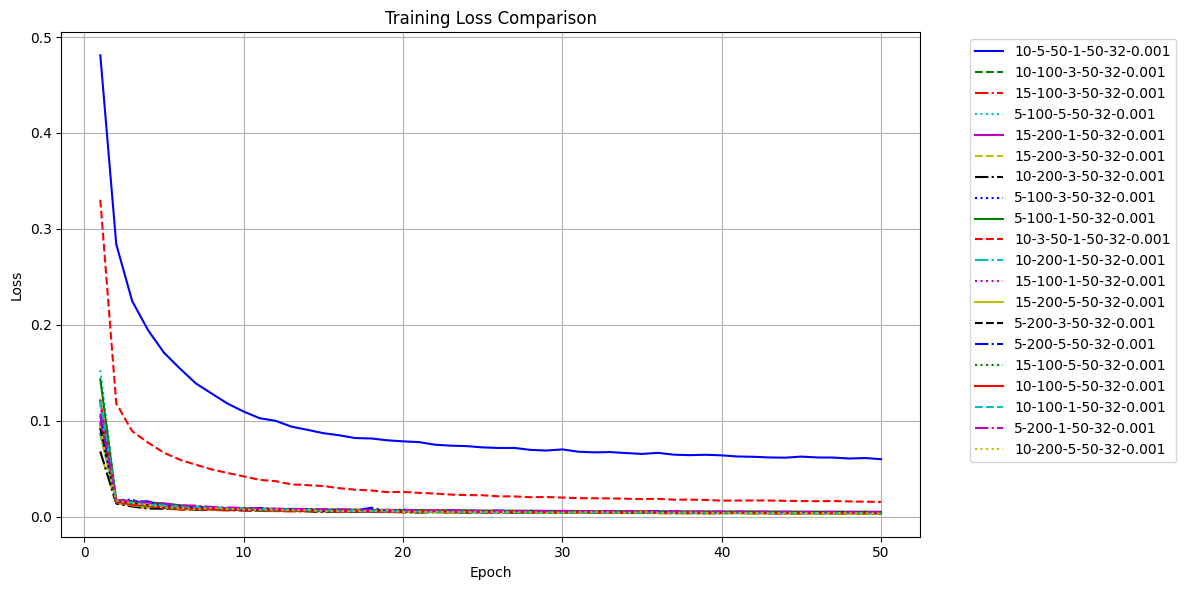

Comparison plot saved to: loss_comparison.png


In [7]:
import glob
import matplotlib.pyplot as plt
import pandas as pd

loss_files = glob.glob("/kaggle/working/*-loss_results.txt")

plt.figure(figsize=(12, 6))

line_styles = ['-', '--', '-.', ':']
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']

for i, loss_file in enumerate(loss_files):
    try:
        params = loss_file.split('/')[-1].split('-loss_results.txt')[0]
        
        data = pd.read_csv(loss_file, header=0, names=['Epoch', 'Loss'], delimiter=',')
        
        if not data.empty:
            style_idx = i % len(line_styles)
            color_idx = i % len(colors)
            
            plt.plot(data['Epoch'], data['Loss'], 
                    label=params,
                    linestyle=line_styles[style_idx],
                    color=colors[color_idx])
    
    except Exception as e:
        print(f"Error processing {loss_file}: {str(e)}")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(True)

plt.tight_layout()

comparison_filename = "loss_comparison.png"
plt.savefig(comparison_filename, bbox_inches='tight')
plt.show()
print(f"Comparison plot saved to: {comparison_filename}")

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class GRUForecaster:
    def __init__(self, data_path, window_size, hidden_size, num_layers, epochs, batch_size, lr):
        self.data_path = data_path
        self.window_size = window_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        self.mean = 0
        self.std = 1
        
        self.model = None
        self.criterion = nn.MSELoss()
        self.optimizer = None

    class GRUModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers):
            super().__init__()
            self.gru = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )
            self.fc = nn.Linear(hidden_size, 1)
            
        def forward(self, x):
            out, _ = self.gru(x)  
            
            out = out[:, -1, :]
            
            out = self.fc(out)
            return out

    def prepare_data(self):
        # 读取数据
        data = pd.read_csv(self.data_path).values.astype(np.float32)
        
        # 划分训练测试集 (70%训练，30%测试)
        train_size = int(len(data) * 0.7)
        train_data = data[:train_size]
        test_data = data[train_size - self.window_size:]  # 保持窗口连续性
        
        # 标准化数据
        self.mean = train_data.mean()
        self.std = train_data.std()
        train_data = (train_data - self.mean) / self.std
        test_data = (test_data - self.mean) / self.std

        def create_samples(dataset):
            X, y = [], []
            for i in range(len(dataset) - self.window_size):
                X.append(dataset[i:i + self.window_size])
                y.append(dataset[i + self.window_size])
            return np.array(X), np.array(y)

        X_train, y_train = create_samples(train_data)
        X_test, y_test = create_samples(test_data)

        self.X_train = torch.from_numpy(X_train).float().view(-1, self.window_size, 1)
        self.y_train = torch.from_numpy(y_train).float().view(-1, 1)
        self.X_test = torch.from_numpy(X_test).float().view(-1, self.window_size, 1)
        self.y_test = torch.from_numpy(y_test).float().view(-1, 1)

    def build_model(self):
        self.model = self.GRUModel(
            input_size=1,  # 单变量时间序列
            hidden_size=self.hidden_size,
            num_layers=self.num_layers
        ).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

    def train(self):
        train_dataset = TimeSeriesDataset(self.X_train, self.y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for epoch in range(self.epochs):
            total_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                self.optimizer.zero_grad()
                
                outputs = self.model(X_batch)
                
                loss = self.criterion(outputs, y_batch)
                
                loss.backward()
                
                self.optimizer.step()
                
                total_loss += loss.item()
            
            avg_loss = total_loss / len(train_loader)
            print(f'Epoch [{epoch+1}/{self.epochs}], Loss: {avg_loss:.6f}')

        torch.save(self.model.state_dict(), 'gru_model.pth')
        print("Training completed. Model saved as 'gru_model.pth'")

    def test(self):
        test_dataset = TimeSeriesDataset(self.X_test, self.y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)

        self.model.load_state_dict(torch.load('gru_model.pth'))
        self.model.eval()
        
        predictions = []
        actuals = []
        
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)

                pred = self.model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())

        predictions = np.array(predictions).flatten() * self.std + self.mean
        actuals = np.array(actuals).flatten() * self.std + self.mean

        mse = np.mean((predictions - actuals) ** 2)
        print(f'Test MSE: {mse:.6f}')
        
        return actuals, predictions

    def plot_results(self, actuals, predictions):
        plt.figure(figsize=(15, 6))
        plt.plot(actuals, label='Actual Values', color='blue', alpha=0.6)
        plt.plot(predictions, label='GRU Predictions', color='red', alpha=0.8, linestyle='--')
        plt.title('Time Series Forecasting with GRU')
        plt.xlabel('Time Steps')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.savefig('gru_forecasting_results.png')
        plt.close()

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class GRUForecaster:
    def __init__(self, data_path, window_size, hidden_size, num_layers, epochs, batch_size, lr, forecast_steps=5):
        self.data_path = data_path
        self.window_size = window_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.forecast_steps = forecast_steps  # 新增：预测步数
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # 数据标准化参数
        self.mean = 0
        self.std = 1
        
        # 模型组件
        self.model = None
        self.criterion = nn.MSELoss()
        self.optimizer = None

    class GRUModel(nn.Module):
        def __init__(self, input_size, hidden_size, num_layers, forecast_steps):
            super().__init__()
            self.forecast_steps = forecast_steps
            self.gru = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True
            )
            self.fc = nn.Linear(hidden_size, forecast_steps)  # 输出维度改为forecast_steps
            
        def forward(self, x):
            out, _ = self.gru(x)
            out = out[:, -1, :]  # 取最后一个时间步的隐藏状态
            out = self.fc(out)
            return out

    def prepare_data(self):
        # 读取数据
        data = pd.read_csv(self.data_path).values.astype(np.float32)
        
        # 划分训练测试集 (70%训练，30%测试)
        train_size = int(len(data) * 0.7)
        train_data = data[:train_size]
        test_data = data[train_size - self.window_size:]  # 保持窗口连续性
        
        # 标准化数据
        self.mean = train_data.mean()
        self.std = train_data.std()
        train_data = (train_data - self.mean) / self.std
        test_data = (test_data - self.mean) / self.std

        def create_samples(dataset):
            X, y = [], []
            # 修改：y现在包含未来forecast_steps个时间点的值
            for i in range(len(dataset) - self.window_size - self.forecast_steps + 1):
                X.append(dataset[i:i + self.window_size])
                y.append(dataset[i + self.window_size:i + self.window_size + self.forecast_steps])
            return np.array(X), np.array(y)

        X_train, y_train = create_samples(train_data)
        X_test, y_test = create_samples(test_data)

        self.X_train = torch.from_numpy(X_train).float().view(-1, self.window_size, 1)
        self.y_train = torch.from_numpy(y_train).float().view(-1, self.forecast_steps)
        self.X_test = torch.from_numpy(X_test).float().view(-1, self.window_size, 1)
        self.y_test = torch.from_numpy(y_test).float().view(-1, self.forecast_steps)

    def build_model(self):
        self.model = self.GRUModel(
            input_size=1,  # 单变量时间序列
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            forecast_steps=self.forecast_steps
        ).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.lr)

    def train(self):
        train_dataset = TimeSeriesDataset(self.X_train, self.y_train)
        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)
        
        self.model.train()
        for epoch in range(self.epochs):
            total_loss = 0
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                self.optimizer.zero_grad()
                outputs = self.model(X_batch)
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                self.optimizer.step()
                
                total_loss += loss.item()
            
            avg_loss = total_loss / len(train_loader)
            print(f'Epoch [{epoch+1}/{self.epochs}], Loss: {avg_loss:.6f}')

        torch.save(self.model.state_dict(), 'gru_model.pth')
        print("Training completed. Model saved as 'gru_model.pth'")

    def test(self):
        test_dataset = TimeSeriesDataset(self.X_test, self.y_test)
        test_loader = DataLoader(test_dataset, batch_size=self.batch_size, shuffle=False)

        self.model.load_state_dict(torch.load('gru_model.pth'))
        self.model.eval()
        
        predictions = []
        actuals = []
        
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(self.device)
                pred = self.model(X_batch).cpu().numpy()
                predictions.extend(pred)
                actuals.extend(y_batch.numpy())

        # 反标准化
        predictions = np.array(predictions) * self.std + self.mean
        actuals = np.array(actuals) * self.std + self.mean

        # 计算每一步的MSE
        for step in range(self.forecast_steps):
            mse = np.mean((predictions[:, step] - actuals[:, step]) ** 2)
            print(f'Test MSE (step {step+1}): {mse:.6f}')
        
        # 为了保持图像不变，只返回第一步的预测结果
        return actuals[:, 0], predictions[:, 0]

    def plot_results(self, actuals, predictions):
        plt.figure(figsize=(15, 6))
        plt.plot(actuals, label='Actual Values', color='blue', alpha=0.6)
        plt.plot(predictions, label='GRU Predictions', color='red', alpha=0.8, linestyle='--')
        plt.title('Time Series Forecasting with GRU (First Step Only)')
        plt.xlabel('Time Steps')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True)
        plt.savefig('gru_multi_forecasting_results.png')
        plt.close()

if __name__ == "__main__":
    forecaster = GRUForecaster(
        data_path='/kaggle/input/ucr-ecg/UCR_ECG1_10000_11800_12100.txt',
        window_size=10,     
        hidden_size=64,     
        num_layers=2,       
        epochs=50,         
        batch_size=32,      
        lr=0.001,
        forecast_steps=5  # 设置预测步数
    )
    
    forecaster.prepare_data()
    forecaster.build_model()
    forecaster.train()
    actuals, predictions = forecaster.test()
    forecaster.plot_results(actuals, predictions)

Epoch [1/50], Loss: 0.379855
Epoch [2/50], Loss: 0.170152
Epoch [3/50], Loss: 0.106484
Epoch [4/50], Loss: 0.085127
Epoch [5/50], Loss: 0.079156
Epoch [6/50], Loss: 0.073631
Epoch [7/50], Loss: 0.071629
Epoch [8/50], Loss: 0.067542
Epoch [9/50], Loss: 0.068761
Epoch [10/50], Loss: 0.064921
Epoch [11/50], Loss: 0.063286
Epoch [12/50], Loss: 0.066516
Epoch [13/50], Loss: 0.064092
Epoch [14/50], Loss: 0.059959
Epoch [15/50], Loss: 0.059653
Epoch [16/50], Loss: 0.062834
Epoch [17/50], Loss: 0.056793
Epoch [18/50], Loss: 0.056754
Epoch [19/50], Loss: 0.055796
Epoch [20/50], Loss: 0.056566
Epoch [21/50], Loss: 0.054713
Epoch [22/50], Loss: 0.055021
Epoch [23/50], Loss: 0.053567
Epoch [24/50], Loss: 0.054014
Epoch [25/50], Loss: 0.058365
Epoch [26/50], Loss: 0.055441
Epoch [27/50], Loss: 0.052001
Epoch [28/50], Loss: 0.051243
Epoch [29/50], Loss: 0.052285
Epoch [30/50], Loss: 0.050689
Epoch [31/50], Loss: 0.051415
Epoch [32/50], Loss: 0.049918
Epoch [33/50], Loss: 0.049289
Epoch [34/50], Loss

/tmp/ipykernel_19/914198306.py:127: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load('gru_model.pth'))


Test MSE (step 1): 0.826356
Test MSE (step 2): 1.876007
Test MSE (step 3): 3.815467
Test MSE (step 4): 10.351273
Test MSE (step 5): 28.499710
